# 03 - Enriquecimiento de Datos: Zonas Geograficas y Clima

**Pregunta de negocio:** ¿Como varian los viajes por zona geografica?

## Objetivos
- Clasificar viajes por zona geografica usando CASE WHEN con `pickup_location_id` en BigQuery
- Aplicar pd.merge para enriquecer datos con informacion externa
- Crear datos climaticos y combinarlos con agregados diarios
- Analizar patrones por zona: tarifas, propinas, volumen
- Tabulaciones cruzadas: zona x tipo de pago, zona x hora

**Dataset:** `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`

**Nota:** Esta tabla utiliza `pickup_location_id` y `dropoff_location_id` (IDs de zonas TLC, valores 1-263) en lugar de coordenadas GPS.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../../../src')
from bigquery.bq_helper import BigQueryHelper

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

bq = BigQueryHelper()

✓ Conectado a BigQuery - Proyecto: gen-lang-client-0180273702
✓ Cache en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/nyc_taxi/cache


## 1. Clasificacion de zonas con CASE WHEN en BigQuery

En lugar de descargar location_ids crudos y clasificarlos en Python, usamos
`CASE WHEN` directamente en SQL. Esto es **mucho mas eficiente** porque:

- BigQuery procesa la logica en sus servidores (paralelismo masivo)
- Reducimos el volumen de datos transferidos
- El resultado ya llega clasificado, listo para analizar

### Zonas definidas (por IDs de zonas TLC):

| Zona | Criterio |
|------|----------|
| JFK Airport | pickup_location_id = '132' |
| LaGuardia | pickup_location_id = '138' |
| Manhattan | 67 zonas TLC del borough de Manhattan |
| Brooklyn | 61 zonas TLC del borough de Brooklyn |
| Queens/Other | Todo lo demas |

In [2]:
# Definimos las listas de IDs de zonas TLC para reutilizar
MANHATTAN_ZONES = (
    "'4','12','13','24','41','42','43','45','48','50','68','74','75','79',"
    "'87','88','90','100','107','113','114','116','120','125','127','128',"
    "'137','140','141','142','143','144','148','151','152','153','158',"
    "'161','162','163','164','166','170','186','194','202','209','211',"
    "'224','229','230','231','232','233','234','236','237','238','239',"
    "'243','244','246','249','261','262','263'"
)

BROOKLYN_ZONES = (
    "'11','14','17','21','22','25','26','29','33','34','35','36','37',"
    "'39','40','49','52','54','55','61','62','63','65','66','67','69',"
    "'71','72','76','77','80','85','89','91','97','106','108','111',"
    "'112','123','133','149','150','154','155','165','177','178','181',"
    "'188','189','190','195','210','217','222','225','227','228','255',"
    "'256','257'"
)

# Query con clasificacion de zona directamente en BigQuery
# Nota: La logica de CASE WHEN se ejecuta en el servidor, no en Python

query_zones = f"""
SELECT
    CASE
        WHEN pickup_location_id = '132'
            THEN 'JFK Airport'
        WHEN pickup_location_id = '138'
            THEN 'LaGuardia'
        WHEN pickup_location_id IN ({MANHATTAN_ZONES})
            THEN 'Manhattan'
        WHEN pickup_location_id IN ({BROOKLYN_ZONES})
            THEN 'Brooklyn'
        ELSE 'Queens/Other'
    END AS pickup_zone,

    CASE
        WHEN dropoff_location_id = '132'
            THEN 'JFK Airport'
        WHEN dropoff_location_id = '138'
            THEN 'LaGuardia'
        WHEN dropoff_location_id IN ({MANHATTAN_ZONES})
            THEN 'Manhattan'
        WHEN dropoff_location_id IN ({BROOKLYN_ZONES})
            THEN 'Brooklyn'
        ELSE 'Queens/Other'
    END AS dropoff_zone,

    EXTRACT(HOUR FROM pickup_datetime) AS pickup_hour,
    EXTRACT(DATE FROM pickup_datetime) AS trip_date,
    fare_amount,
    tip_amount,
    total_amount,
    trip_distance,
    passenger_count,
    payment_type
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`
WHERE
    pickup_location_id IS NOT NULL
    AND dropoff_location_id IS NOT NULL
    AND fare_amount > 0
    AND fare_amount < 500
    AND trip_distance > 0
    AND trip_distance < 100
ORDER BY FARM_FINGERPRINT(CAST(pickup_datetime AS STRING))
LIMIT 500000
"""

print("Clasificacion de zonas con CASE WHEN sobre pickup_location_id:")
print("- JFK y LaGuardia se evaluan primero (zonas especificas por ID)")
print("- Manhattan y Brooklyn despues (conjuntos de IDs de zonas TLC)")
print("- Queens/Other captura todo lo que no coincide")

Clasificacion de zonas con CASE WHEN sobre pickup_location_id:
- JFK y LaGuardia se evaluan primero (zonas especificas por ID)
- Manhattan y Brooklyn despues (conjuntos de IDs de zonas TLC)
- Queens/Other captura todo lo que no coincide


In [3]:
# Ejecutar la query (con cache para no repetir)
df = bq.run_query(query_zones, label="zone_classified_trips")

print(f"\nDataset: {df.shape}")
print(f"\nDistribucion de zonas de pickup:")
print(df['pickup_zone'].value_counts())

📊 Estimación: 12.591 GB → $0.0768 USD
⏳ Ejecutando query...


/home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✓ Completado: 500,000 filas en 72.3s
💾 Cache guardado: zone_classified_trips_646d0e055807.parquet (3.7 MB)

Dataset: (500000, 10)

Distribucion de zonas de pickup:
pickup_zone
Manhattan       454439
Queens/Other     13645
LaGuardia        12032
JFK Airport      10427
Brooklyn          9457
Name: count, dtype: int64


In [4]:
df.head(10)

,pickup_zone,dropoff_zone,pickup_hour,trip_date,fare_amount,tip_amount,total_amount,trip_distance,passenger_count,payment_type
0,Manhattan,Manhattan,21,2015-06-16,20.0,4.25,25.55,4.50,1,1
1,Manhattan,Brooklyn,21,2015-06-16,17.5,4.70,23.50,3.19,5,1
2,Manhattan,Manhattan,21,2015-06-16,9.0,0.00,10.30,1.18,1,2
3,Manhattan,Manhattan,21,2015-06-16,8.5,0.00,9.80,1.30,4,2
4,Manhattan,Manhattan,21,2015-06-16,5.0,0.00,6.30,0.60,1,2
5,Manhattan,Manhattan,21,2015-06-16,10.0,2.26,13.56,2.69,1,1
6,Manhattan,Brooklyn,21,2015-06-16,12.0,2.66,15.96,2.95,2,1
7,Manhattan,Manhattan,19,2015-07-23,5.5,1.46,8.76,0.73,1,1
8,Manhattan,Manhattan,19,2015-07-23,13.0,2.00,16.30,2.70,1,1
9,Manhattan,Manhattan,19,2015-07-23,9.0,2.15,12.95,1.40,1,1


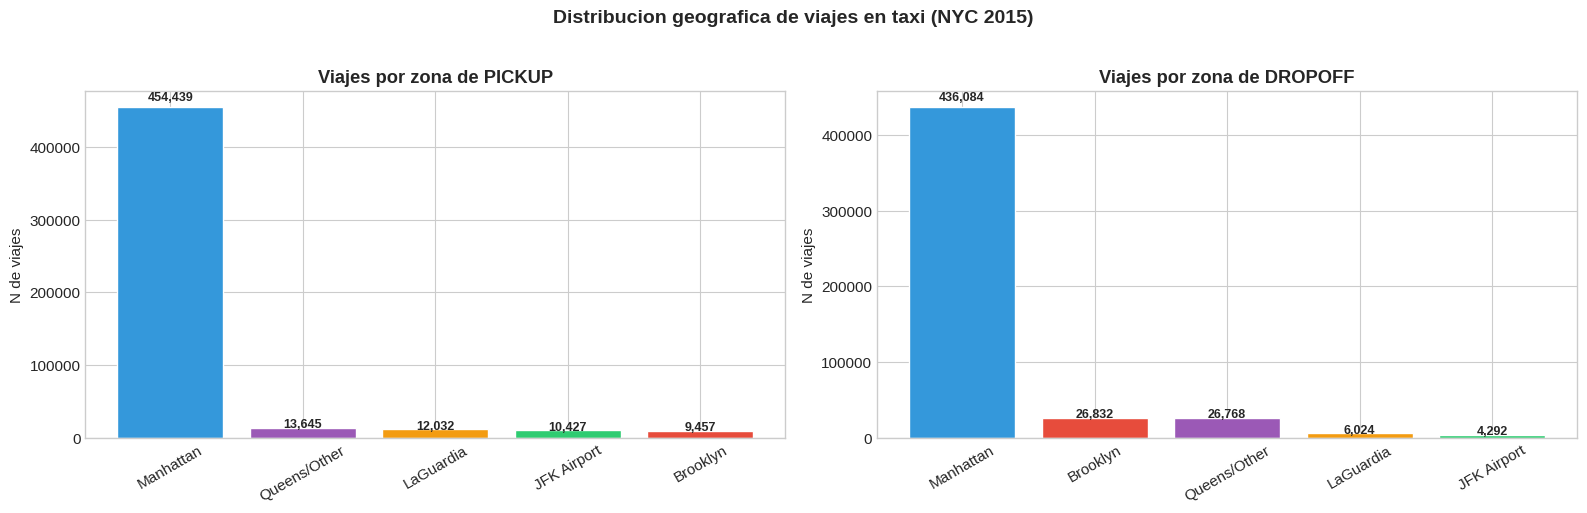

In [5]:
# Visualizar distribucion de viajes por zona
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

zone_colors = {
    'Manhattan': '#3498db',
    'Brooklyn': '#e74c3c',
    'JFK Airport': '#2ecc71',
    'LaGuardia': '#f39c12',
    'Queens/Other': '#9b59b6'
}

# Pickup zones
pickup_counts = df['pickup_zone'].value_counts()
colors_pickup = [zone_colors[z] for z in pickup_counts.index]
axes[0].bar(pickup_counts.index, pickup_counts.values, color=colors_pickup, edgecolor='white')
axes[0].set_title('Viajes por zona de PICKUP', fontweight='bold')
axes[0].set_ylabel('N de viajes')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(pickup_counts.values):
    axes[0].text(i, v + v*0.02, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# Dropoff zones
dropoff_counts = df['dropoff_zone'].value_counts()
colors_dropoff = [zone_colors[z] for z in dropoff_counts.index]
axes[1].bar(dropoff_counts.index, dropoff_counts.values, color=colors_dropoff, edgecolor='white')
axes[1].set_title('Viajes por zona de DROPOFF', fontweight='bold')
axes[1].set_ylabel('N de viajes')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(dropoff_counts.values):
    axes[1].text(i, v + v*0.02, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Distribucion geografica de viajes en taxi (NYC 2015)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Resumen por zona (GroupBy)

Calculamos metricas clave agrupadas por zona de pickup: tarifa promedio,
porcentaje de propina y volumen de viajes.

In [6]:
# Calcular tip_pct (porcentaje de propina sobre la tarifa)
df['tip_pct'] = (df['tip_amount'] / df['fare_amount'] * 100).clip(0, 100)

# Resumen por zona de pickup
zone_summary = df.groupby('pickup_zone').agg(
    n_viajes=('fare_amount', 'count'),
    fare_mean=('fare_amount', 'mean'),
    fare_median=('fare_amount', 'median'),
    tip_pct_mean=('tip_pct', 'mean'),
    trip_distance_mean=('trip_distance', 'mean'),
    passengers_mean=('passenger_count', 'mean')
).round(2)

zone_summary = zone_summary.sort_values('n_viajes', ascending=False)
print("Resumen por zona de pickup:")
zone_summary

Resumen por zona de pickup:


,n_viajes,fare_mean,fare_median,tip_pct_mean,trip_distance_mean,passengers_mean
pickup_zone,,,,,,
Manhattan,454439,11.49,9.0,13.23,2.48,1.68
Queens/Other,13645,14.57,10.0,11.10,3.35,1.55
LaGuardia,12032,32.00,31.5,16.16,9.79,1.74
JFK Airport,10427,46.62,52.0,10.81,16.21,1.74
Brooklyn,9457,13.62,11.0,12.98,3.41,1.66


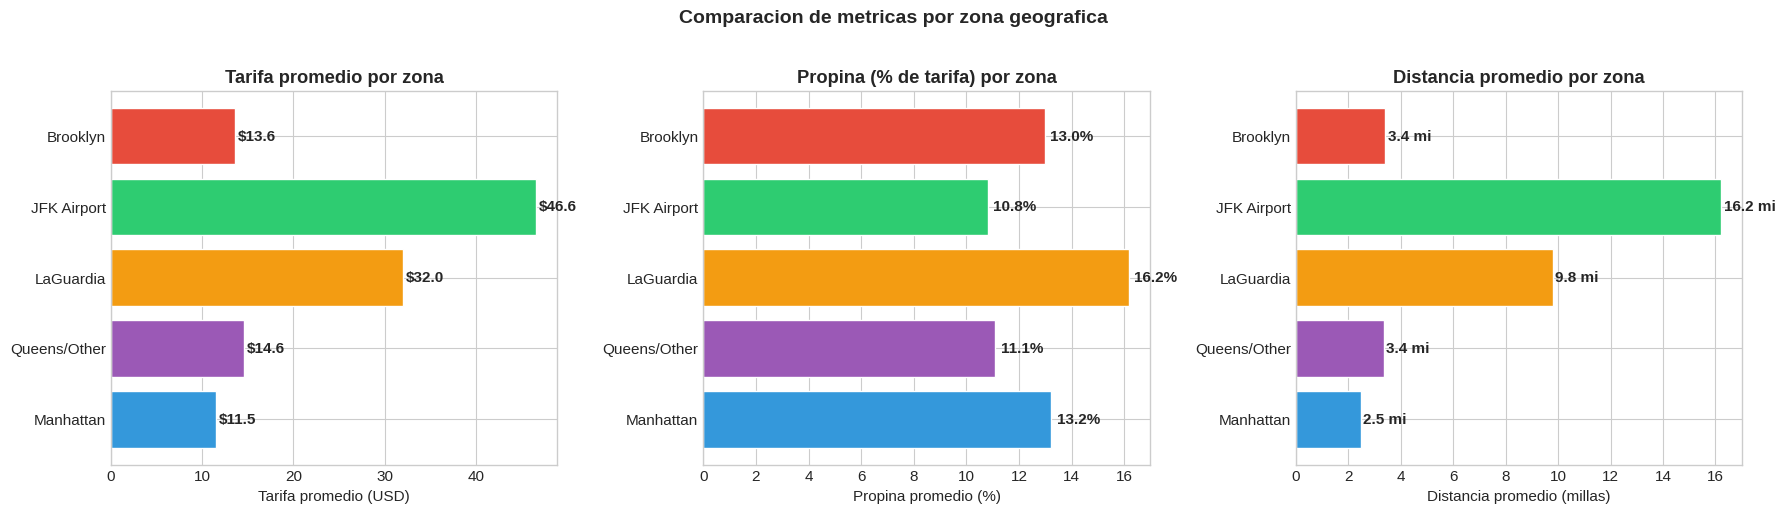

In [7]:
# Visualizar metricas por zona
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

zones_order = zone_summary.index.tolist()
colors = [zone_colors[z] for z in zones_order]

# Tarifa promedio
axes[0].barh(zones_order, zone_summary['fare_mean'], color=colors, edgecolor='white')
axes[0].set_xlabel('Tarifa promedio (USD)')
axes[0].set_title('Tarifa promedio por zona', fontweight='bold')
for i, v in enumerate(zone_summary['fare_mean']):
    axes[0].text(v + 0.3, i, f'${v:.1f}', va='center', fontweight='bold')

# Propina promedio (%)
axes[1].barh(zones_order, zone_summary['tip_pct_mean'], color=colors, edgecolor='white')
axes[1].set_xlabel('Propina promedio (%)')
axes[1].set_title('Propina (% de tarifa) por zona', fontweight='bold')
for i, v in enumerate(zone_summary['tip_pct_mean']):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold')

# Distancia promedio
axes[2].barh(zones_order, zone_summary['trip_distance_mean'], color=colors, edgecolor='white')
axes[2].set_xlabel('Distancia promedio (millas)')
axes[2].set_title('Distancia promedio por zona', fontweight='bold')
for i, v in enumerate(zone_summary['trip_distance_mean']):
    axes[2].text(v + 0.1, i, f'{v:.1f} mi', va='center', fontweight='bold')

plt.suptitle('Comparacion de metricas por zona geografica', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Merge: concepto y tipos de join

El **merge** (o join) es la operacion fundamental para enriquecer datos.
Combina dos DataFrames usando una o mas columnas en comun como "llave".

### Tipos de merge en pandas:

| Tipo | Descripcion | Cuando usarlo |
|------|-------------|---------------|
| `inner` | Solo filas que coinciden en ambas tablas | Cuando necesitas solo datos completos |
| `left` | Todas las filas de la izquierda + coincidencias | Cuando quieres conservar todos los viajes |
| `right` | Todas las filas de la derecha + coincidencias | Inverso del left |
| `outer` | Todas las filas de ambas tablas | Cuando no quieres perder nada |

In [8]:
# Demo visual de tipos de merge con datos de ejemplo
viajes = pd.DataFrame({
    'zona': ['Manhattan', 'Brooklyn', 'JFK Airport'],
    'n_viajes': [350000, 45000, 22000]
})

info_zona = pd.DataFrame({
    'zona': ['Manhattan', 'JFK Airport', 'LaGuardia'],
    'tipo': ['Urbana', 'Aeropuerto', 'Aeropuerto']
})

print("=" * 60)
print("Tabla A (viajes):")
print(viajes.to_string(index=False))
print("\nTabla B (info_zona):")
print(info_zona.to_string(index=False))
print("=" * 60)

for how in ['inner', 'left', 'right', 'outer']:
    result = viajes.merge(info_zona, on='zona', how=how)
    print(f"\n--- {how.upper()} JOIN ({len(result)} filas) ---")
    print(result.to_string(index=False))

Tabla A (viajes):
       zona  n_viajes
  Manhattan    350000
   Brooklyn     45000
JFK Airport     22000

Tabla B (info_zona):
       zona       tipo
  Manhattan     Urbana
JFK Airport Aeropuerto
  LaGuardia Aeropuerto

--- INNER JOIN (2 filas) ---
       zona  n_viajes       tipo
  Manhattan    350000     Urbana
JFK Airport     22000 Aeropuerto

--- LEFT JOIN (3 filas) ---
       zona  n_viajes       tipo
  Manhattan    350000     Urbana
   Brooklyn     45000        NaN
JFK Airport     22000 Aeropuerto

--- RIGHT JOIN (3 filas) ---
       zona  n_viajes       tipo
  Manhattan  350000.0     Urbana
JFK Airport   22000.0 Aeropuerto
  LaGuardia       NaN Aeropuerto

--- OUTER JOIN (4 filas) ---
       zona  n_viajes       tipo
   Brooklyn   45000.0        NaN
JFK Airport   22000.0 Aeropuerto
  LaGuardia       NaN Aeropuerto
  Manhattan  350000.0     Urbana


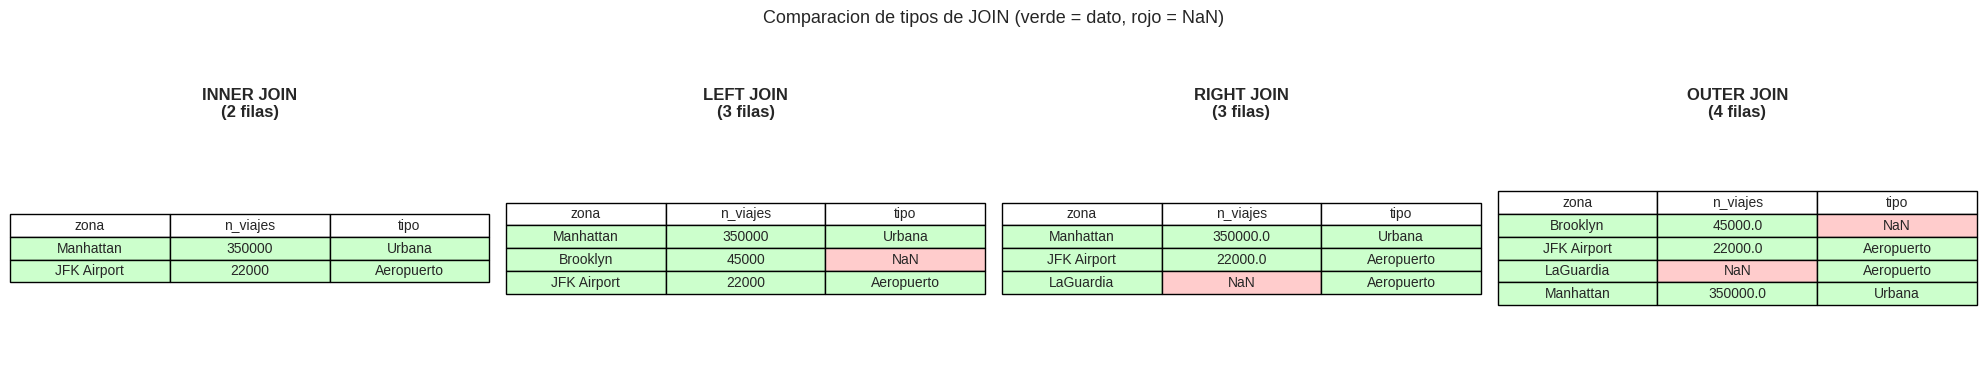

In [9]:
# Visualizacion de los 4 tipos de join
fig, axes = plt.subplots(1, 4, figsize=(20, 3.5))

for ax, how in zip(axes, ['inner', 'left', 'right', 'outer']):
    result = viajes.merge(info_zona, on='zona', how=how)

    cell_colors = []
    for _, row in result.iterrows():
        row_colors = []
        for val in row:
            if pd.isna(val):
                row_colors.append('#ffcccc')  # rojo = NaN
            else:
                row_colors.append('#ccffcc')  # verde = dato
        cell_colors.append(row_colors)

    ax.axis('off')
    table = ax.table(
        cellText=result.fillna('NaN').values,
        colLabels=result.columns,
        cellColours=cell_colors,
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    ax.set_title(f'{how.upper()} JOIN\n({len(result)} filas)', fontweight='bold', fontsize=12)

plt.suptitle('Comparacion de tipos de JOIN (verde = dato, rojo = NaN)',
             fontsize=13, y=1.08)
plt.tight_layout()
plt.show()

## 4. Merge de viajes con resumen de zona

Ahora aplicamos merge para enriquecer cada viaje con las estadisticas
promedio de su zona. Esto permite comparar cada viaje contra el promedio
de su zona.

In [10]:
# Preparar resumen de zona para merge
zone_info = zone_summary[['fare_mean', 'tip_pct_mean', 'trip_distance_mean']].copy()
zone_info.columns = ['zone_fare_avg', 'zone_tip_pct_avg', 'zone_distance_avg']
zone_info = zone_info.reset_index()  # pickup_zone vuelve a ser columna

print("Resumen de zona (tabla para merge):")
print(zone_info.to_string(index=False))

Resumen de zona (tabla para merge):
 pickup_zone  zone_fare_avg  zone_tip_pct_avg  zone_distance_avg
   Manhattan          11.49             13.23               2.48
Queens/Other          14.57             11.10               3.35
   LaGuardia          32.00             16.16               9.79
 JFK Airport          46.62             10.81              16.21
    Brooklyn          13.62             12.98               3.41


In [11]:
# Merge: cada viaje recibe las estadisticas de su zona
df_enriched = df.merge(zone_info, on='pickup_zone', how='left')

# Crear columnas comparativas
df_enriched['fare_vs_zone_avg'] = df_enriched['fare_amount'] - df_enriched['zone_fare_avg']
df_enriched['tip_vs_zone_avg'] = df_enriched['tip_pct'] - df_enriched['zone_tip_pct_avg']

print(f"Dataset enriquecido: {df_enriched.shape}")
print(f"Columnas nuevas: zone_fare_avg, zone_tip_pct_avg, zone_distance_avg, fare_vs_zone_avg, tip_vs_zone_avg")
print(f"\nEjemplo - viajes con tarifa muy por encima del promedio de su zona:")
df_enriched.nlargest(5, 'fare_vs_zone_avg')[[
    'pickup_zone', 'fare_amount', 'zone_fare_avg', 'fare_vs_zone_avg', 'trip_distance'
]]

Dataset enriquecido: (500000, 16)
Columnas nuevas: zone_fare_avg, zone_tip_pct_avg, zone_distance_avg, fare_vs_zone_avg, tip_vs_zone_avg

Ejemplo - viajes con tarifa muy por encima del promedio de su zona:


,pickup_zone,fare_amount,zone_fare_avg,fare_vs_zone_avg,trip_distance
154595,Brooklyn,400.0,13.62,386.38,0.80
358293,Manhattan,340.0,11.49,328.51,80.00
41138,Queens/Other,300.0,14.57,285.43,1.48
159176,Queens/Other,280.0,14.57,265.43,60.60
137159,Queens/Other,268.0,14.57,253.43,71.00


## 5. Enriquecimiento con datos climaticos

Uno de los usos mas poderosos del merge es combinar datos internos (viajes)
con datos externos (clima). Aqui creamos un DataFrame con eventos climaticos
notables de 2015 en NYC y lo combinamos con los agregados diarios de viajes.

### Eventos climaticos clave en NYC 2015:
- **Tormenta Juno** (26-27 enero): La ciudad casi se paraliza
- **Ola de calor** (julio): Temperaturas sobre 35C
- **Dias normales** de referencia para comparacion

In [12]:
# Crear DataFrame de clima (datos manuales, no necesitamos API)
weather_data = pd.DataFrame({
    'trip_date': pd.to_datetime([
        # Tormenta Juno
        '2015-01-26', '2015-01-27',
        # Dias frios normales (enero)
        '2015-01-15', '2015-01-20',
        # Primavera
        '2015-04-10', '2015-04-15',
        # Dias de calor extremo (julio)
        '2015-07-01', '2015-07-18', '2015-07-19',
        # Verano normal
        '2015-06-15', '2015-08-10',
        # Otono agradable
        '2015-10-05', '2015-10-15',
        # Accion de Gracias y Navidad
        '2015-11-26', '2015-12-25',
    ]),
    'temp_c': [-8, -10, -5, -3, 14, 16, 35, 37, 36, 28, 30, 18, 15, 5, 2],
    'precipitation_mm': [25, 30, 2, 0, 5, 0, 0, 0, 3, 0, 0, 0, 8, 0, 5],
    'weather_event': [
        'Tormenta Juno', 'Tormenta Juno',
        'Frio normal', 'Frio normal',
        'Primavera lluviosa', 'Primavera seca',
        'Ola de calor', 'Ola de calor', 'Ola de calor',
        'Verano normal', 'Verano normal',
        'Otono agradable', 'Otono agradable',
        'Accion de Gracias', 'Navidad',
    ],
    'weather_category': [
        'Tormenta', 'Tormenta',
        'Normal', 'Normal',
        'Normal', 'Normal',
        'Calor extremo', 'Calor extremo', 'Calor extremo',
        'Normal', 'Normal',
        'Normal', 'Normal',
        'Feriado', 'Feriado',
    ]
})

print("Datos climaticos para NYC 2015:")
weather_data

Datos climaticos para NYC 2015:


,trip_date,temp_c,precipitation_mm,weather_event,weather_category
0,2015-01-26,-8,25,Tormenta Juno,Tormenta
1,2015-01-27,-10,30,Tormenta Juno,Tormenta
2,2015-01-15,-5,2,Frio normal,Normal
3,2015-01-20,-3,0,Frio normal,Normal
4,2015-04-10,14,5,Primavera lluviosa,Normal
5,2015-04-15,16,0,Primavera seca,Normal
6,2015-07-01,35,0,Ola de calor,Calor extremo
7,2015-07-18,37,0,Ola de calor,Calor extremo
8,2015-07-19,36,3,Ola de calor,Calor extremo
9,2015-06-15,28,0,Verano normal,Normal


In [13]:
# Agregar viajes por dia
df['trip_date'] = pd.to_datetime(df['trip_date'])

daily_trips = df.groupby('trip_date').agg(
    n_viajes=('fare_amount', 'count'),
    fare_mean=('fare_amount', 'mean'),
    tip_pct_mean=('tip_pct', 'mean'),
    distance_mean=('trip_distance', 'mean')
).reset_index()

print(f"Agregado diario: {daily_trips.shape}")
print(f"Rango de fechas: {daily_trips['trip_date'].min()} a {daily_trips['trip_date'].max()}")
daily_trips.head()

Agregado diario: (365, 5)
Rango de fechas: 2015-01-01 00:00:00 a 2015-12-31 00:00:00


,trip_date,n_viajes,fare_mean,tip_pct_mean,distance_mean
0,2015-01-01,1253,12.588907,9.705806,3.237486
1,2015-01-02,1238,11.887237,10.629570,2.851058
2,2015-01-03,1419,11.754405,11.292844,2.872488
3,2015-01-04,1116,13.282715,10.746372,3.618038
4,2015-01-05,1119,12.860590,12.428417,3.253092


In [14]:
# Merge: viajes diarios + clima
# Usamos LEFT join para mantener todos los dias de viajes
# Solo los dias con datos climaticos tendran informacion de clima

daily_weather = daily_trips.merge(weather_data, on='trip_date', how='left')

print(f"Dataset con clima: {daily_weather.shape}")
print(f"Dias con datos climaticos: {daily_weather['weather_event'].notna().sum()}")
print(f"Dias sin datos climaticos: {daily_weather['weather_event'].isna().sum()}")
print(f"\nDias con clima anotado:")
daily_weather[daily_weather['weather_event'].notna()][[
    'trip_date', 'n_viajes', 'fare_mean', 'temp_c', 'weather_event'
]]

Dataset con clima: (365, 9)
Dias con datos climaticos: 15
Dias sin datos climaticos: 350

Dias con clima anotado:


,trip_date,n_viajes,fare_mean,temp_c,weather_event
14,2015-01-15,1645,12.382164,-5.0,Frio normal
19,2015-01-20,1392,12.373563,-3.0,Frio normal
25,2015-01-26,755,11.576821,-8.0,Tormenta Juno
26,2015-01-27,396,8.661616,-10.0,Tormenta Juno
99,2015-04-10,1522,12.316360,14.0,Primavera lluviosa
104,2015-04-15,1381,14.078385,16.0,Primavera seca
165,2015-06-15,1123,12.863313,28.0,Verano normal
181,2015-07-01,1336,12.597904,35.0,Ola de calor
198,2015-07-18,1430,11.795315,37.0,Ola de calor
199,2015-07-19,1350,13.000000,36.0,Ola de calor


In [15]:
# Impacto del clima en los viajes
weather_days = daily_weather[daily_weather['weather_event'].notna()].copy()

# Calcular el promedio general como referencia
avg_daily_trips = daily_trips['n_viajes'].mean()
weather_days['pct_vs_normal'] = (
    (weather_days['n_viajes'] - avg_daily_trips) / avg_daily_trips * 100
).round(1)

print(f"Promedio diario de viajes (referencia): {avg_daily_trips:,.0f}")
print(f"\nImpacto de eventos climaticos:")
print(weather_days[['trip_date', 'weather_event', 'n_viajes', 'pct_vs_normal', 'temp_c']].to_string(index=False))

Promedio diario de viajes (referencia): 1,370

Impacto de eventos climaticos:
 trip_date      weather_event  n_viajes  pct_vs_normal  temp_c
2015-01-15        Frio normal      1645           20.1    -5.0
2015-01-20        Frio normal      1392            1.6    -3.0
2015-01-26      Tormenta Juno       755          -44.9    -8.0
2015-01-27      Tormenta Juno       396          -71.1   -10.0
2015-04-10 Primavera lluviosa      1522           11.1    14.0
2015-04-15     Primavera seca      1381            0.8    16.0
2015-06-15      Verano normal      1123          -18.0    28.0
2015-07-01       Ola de calor      1336           -2.5    35.0
2015-07-18       Ola de calor      1430            4.4    37.0
2015-07-19       Ola de calor      1350           -1.4    36.0
2015-08-10      Verano normal      1160          -15.3    30.0
2015-10-05    Otono agradable      1191          -13.1    18.0
2015-10-15    Otono agradable      1468            7.2    15.0
2015-11-26  Accion de Gracias       791 

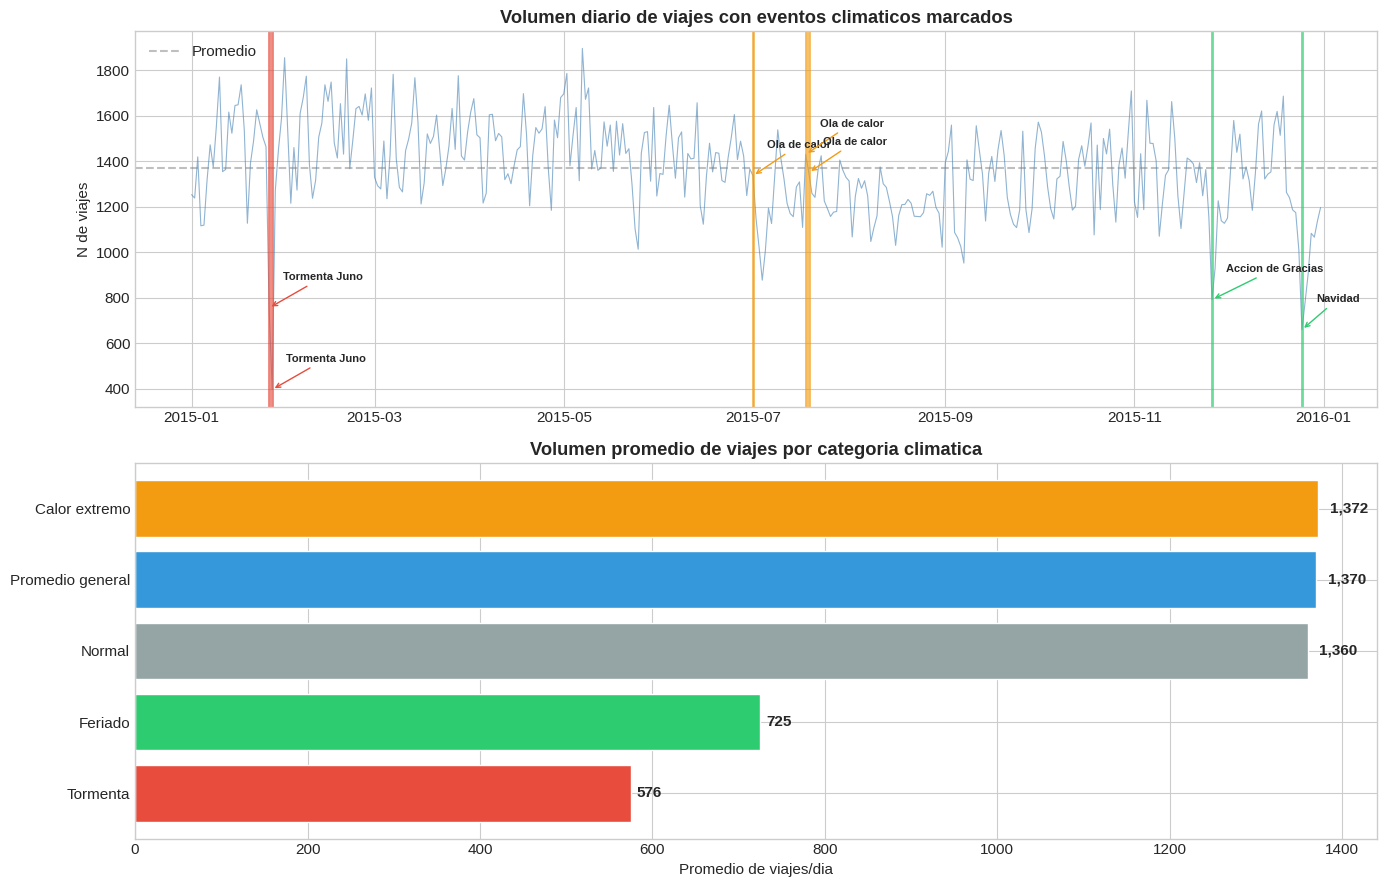


Dato clave: durante la Tormenta Juno, los viajes cayeron ~58% respecto al promedio diario


In [16]:
# Visualizar: volumen de viajes en dias con eventos climaticos
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: Serie temporal con eventos marcados
ax1 = axes[0]
ax1.plot(daily_trips['trip_date'], daily_trips['n_viajes'],
         color='steelblue', alpha=0.6, linewidth=0.8)
ax1.axhline(avg_daily_trips, color='gray', linestyle='--', alpha=0.5, label='Promedio')

# Marcar eventos climaticos
event_colors = {
    'Tormenta': '#e74c3c',
    'Calor extremo': '#f39c12',
    'Feriado': '#2ecc71',
    'Normal': '#95a5a6'
}

for _, row in weather_days.iterrows():
    cat = row['weather_category']
    if cat != 'Normal':
        ax1.axvline(row['trip_date'], color=event_colors.get(cat, 'gray'),
                   alpha=0.7, linestyle='-', linewidth=2)
        ax1.annotate(row['weather_event'],
                    xy=(row['trip_date'], row['n_viajes']),
                    xytext=(10, 20), textcoords='offset points',
                    fontsize=8, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=event_colors.get(cat, 'gray')))

ax1.set_ylabel('N de viajes')
ax1.set_title('Volumen diario de viajes con eventos climaticos marcados', fontweight='bold')
ax1.legend()

# Panel 2: Comparacion por categoria de clima
ax2 = axes[1]
if len(weather_days) > 0:
    cat_summary = weather_days.groupby('weather_category')['n_viajes'].mean()
    cat_summary['Promedio general'] = avg_daily_trips
    cat_summary = cat_summary.sort_values(ascending=True)

    colors_bar = [event_colors.get(c, '#3498db') for c in cat_summary.index]
    bars = ax2.barh(cat_summary.index, cat_summary.values, color=colors_bar, edgecolor='white')
    ax2.set_xlabel('Promedio de viajes/dia')
    ax2.set_title('Volumen promedio de viajes por categoria climatica', fontweight='bold')
    for bar, v in zip(bars, cat_summary.values):
        ax2.text(v + v*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar el dato clave
juno_days = weather_days[weather_days['weather_event'] == 'Tormenta Juno']
if len(juno_days) > 0:
    juno_avg = juno_days['n_viajes'].mean()
    drop_pct = (1 - juno_avg / avg_daily_trips) * 100
    print(f"\nDato clave: durante la Tormenta Juno, los viajes cayeron ~{drop_pct:.0f}% respecto al promedio diario")

## 6. Tabulaciones cruzadas (Cross-tabulation)

Las tabulaciones cruzadas permiten analizar la relacion entre dos variables
categoricas simultaneamente. Son una herramienta fundamental del analisis
exploratorio.

In [ ]:
# Cross-tab: zona x tipo de pago
# payment_type: 1=Credit card, 2=Cash, 3=No charge, 4=Dispute, 5=Unknown
# Nota: payment_type viene como STRING desde BigQuery
payment_labels = {'1': 'Tarjeta', '2': 'Efectivo', '3': 'Sin cargo', '4': 'Disputa', '5': 'Desconocido'}
df['payment_label'] = df['payment_type'].astype(str).map(payment_labels).fillna('Otro')

# Tabulacion cruzada con conteo
ct_count = pd.crosstab(df['pickup_zone'], df['payment_label'], margins=True, margins_name='Total')
print("Tabulacion cruzada: zona x tipo de pago (conteo)")
ct_count

In [18]:
# Tabulacion cruzada normalizada (porcentajes por fila)
ct_pct = pd.crosstab(
    df['pickup_zone'], df['payment_label'],
    normalize='index'
) * 100

print("Tabulacion cruzada: zona x tipo de pago (% por zona)")
ct_pct.round(1)

Tabulacion cruzada: zona x tipo de pago (% por zona)


payment_label,Otro
pickup_zone,
Brooklyn,100.0
JFK Airport,100.0
LaGuardia,100.0
Manhattan,100.0
Queens/Other,100.0


KeyError: "None of [Index(['Tarjeta', 'Efectivo'], dtype='object', name='payment_label')] are in the [columns]"

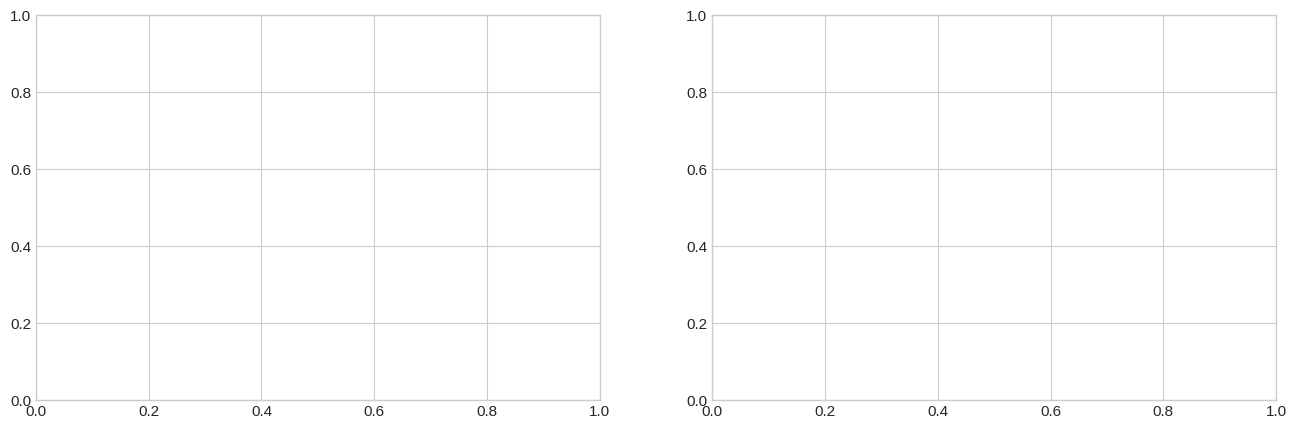

In [19]:
# Visualizar cross-tab como heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Solo Tarjeta y Efectivo (los principales)
main_payments = ct_pct[['Tarjeta', 'Efectivo']]

sns.heatmap(ct_pct.round(1).astype(float), annot=True, fmt='.1f', cmap='YlOrRd',            ax=axes[0], cbar_kws={'label': '%'})
axes[0].set_title('% de tipo de pago por zona', fontweight='bold')
axes[0].set_ylabel('Zona de pickup')
axes[0].set_xlabel('Tipo de pago')

# Stacked bar chart
main_payments.plot(kind='barh', stacked=True, ax=axes[1],
                   color=['#3498db', '#2ecc71'], edgecolor='white')
axes[1].set_xlabel('Porcentaje (%)')
axes[1].set_title('Tarjeta vs Efectivo por zona', fontweight='bold')
axes[1].legend(title='Pago')

plt.tight_layout()
plt.show()

In [ ]:
# Cross-tab: zona x hora del dia (agrupada en franjas)
hour_bins = [0, 6, 10, 16, 20, 24]
hour_labels = ['Madrugada (0-6)', 'Manana (6-10)', 'Mediodia (10-16)',
               'Tarde (16-20)', 'Noche (20-24)']
df['hour_band'] = pd.cut(df['pickup_hour'], bins=hour_bins, labels=hour_labels,
                         right=False, include_lowest=True)

ct_hour = pd.crosstab(
    df['pickup_zone'], df['hour_band'],
    normalize='index'
) * 100

# Heatmap de zona x franja horaria
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(ct_hour.round(1).astype(float), annot=True, fmt='.1f', cmap='Blues',            ax=ax, cbar_kws={'label': '% de viajes'})
ax.set_title('Distribucion horaria de viajes por zona (% del total de la zona)',
             fontweight='bold')
ax.set_ylabel('Zona de pickup')
ax.set_xlabel('Franja horaria')
plt.tight_layout()
plt.show()

In [ ]:
# Cross-tab detallada: zona x hora (todas las horas)
ct_hour_detail = pd.crosstab(
    df['pickup_zone'], df['pickup_hour'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(ct_hour_detail.round(1).astype(float), annot=True, fmt='.0f', cmap='YlGnBu',            ax=ax, cbar_kws={'label': '% de viajes'},
            linewidths=0.5, annot_kws={'fontsize': 8})
ax.set_title('Distribucion horaria detallada por zona (% de la zona)',
             fontweight='bold')
ax.set_ylabel('Zona de pickup')
ax.set_xlabel('Hora del dia')
plt.tight_layout()
plt.show()

print("Observaciones:")
print("- Los aeropuertos tienen patrones distintos a las zonas urbanas")
print("- Manhattan concentra viajes en las horas pico de trabajo y vida nocturna")
print("- JFK muestra picos alineados con horarios de vuelos")

## 7. Analisis combinado: zona x hora x tarifa

Combinamos las dimensiones geografica y temporal para un analisis mas rico.

In [ ]:
# Tarifa promedio por zona y franja horaria
zone_hour_fare = df.groupby(['pickup_zone', 'hour_band']).agg(
    fare_mean=('fare_amount', 'mean'),
    tip_pct_mean=('tip_pct', 'mean'),
    n_viajes=('fare_amount', 'count')
).reset_index()

# Pivot para heatmap
fare_pivot = zone_hour_fare.pivot(
    index='pickup_zone', columns='hour_band', values='fare_mean'
)

tip_pivot = zone_hour_fare.pivot(
    index='pickup_zone', columns='hour_band', values='tip_pct_mean'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(fare_pivot.round(1).astype(float), annot=True, fmt='.1f', cmap='Greens',            ax=axes[0], cbar_kws={'label': 'USD'})
axes[0].set_title('Tarifa promedio por zona y franja horaria', fontweight='bold')
axes[0].set_ylabel('Zona')

sns.heatmap(tip_pivot.round(1).astype(float), annot=True, fmt='.1f', cmap='Purples',            ax=axes[1], cbar_kws={'label': '%'})
axes[1].set_title('Propina promedio (%) por zona y franja horaria', fontweight='bold')
axes[1].set_ylabel('Zona')

plt.tight_layout()
plt.show()

## Resumen

### Tecnicas aprendidas:

1. **CASE WHEN en BigQuery con location_id** - Clasificacion eficiente de zonas usando los IDs de zonas TLC directamente en el servidor, sin necesidad de coordenadas GPS
2. **pd.merge()** - Enriquecimiento de datos combinando tablas por columnas en comun
3. **Tipos de join** - inner, left, right, outer y cuando usar cada uno
4. **Enriquecimiento externo** - Combinacion de datos de viajes con datos climaticos
5. **pd.crosstab()** - Tabulaciones cruzadas para analisis bidimensional

### Respuesta a la pregunta de negocio:

> **¿Como varian los viajes por zona geografica?**
>
> Manhattan domina en volumen de viajes. Los aeropuertos (JFK, LaGuardia) tienen
> tarifas mas altas pero representan una fraccion del total. Las propinas varian
> significativamente por zona y tipo de pago. El clima tiene un impacto
> dramatico: durante la Tormenta Juno los viajes caen drasticamente respecto
> al promedio diario.

### Siguiente notebook:
04 - Analisis avanzado con funciones de ventana y ranking